# Alpha draft model experiment

Load normalized Dota 2 drafts, build PyTorch tensors, create the Alpha model, and prepare a train/validation loop.

In [1]:
import importlib
import json
import sys
from pathlib import Path
from html import escape

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "scripts").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

import scripts.ml.dataset as dataset_module
import scripts.ml.models.alpha as alpha_module

importlib.reload(dataset_module)
importlib.reload(alpha_module)

DatasetMaker = dataset_module.DatasetMaker
AlphaDraftModel = alpha_module.AlphaDraftModel


In [2]:
REAL_DATASET_SIZE = 4_800
SYNTHETIC_DATASET_SIZE = 10_000
BATCH_SIZE = 64
VAL_FRACTION = 0.2
SEED = 42

# Keep every data source represented with the same validation fraction.
SOURCE_REAL = 0
SOURCE_SYNTHETIC = 1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

In [3]:
with DatasetMaker(env_file=str(PROJECT_ROOT / ".env")) as dataset:
    real_matches = dataset.fetch_normalized_match_drafts(REAL_DATASET_SIZE)
    synthetic_matches = dataset.fetch_normalized_synthetic_match_drafts(SYNTHETIC_DATASET_SIZE)

matches = real_matches + synthetic_matches
sources = torch.tensor(
    [SOURCE_REAL] * len(real_matches) + [SOURCE_SYNTHETIC] * len(synthetic_matches),
    dtype=torch.long,
)

len(real_matches), len(synthetic_matches), len(matches), matches[0]


(4800,
 10000,
 14800,
 NormalizedMatchDraft(match_id=8802421773, radiant_hero_ids=[98, 30, 54, 82, 53], dire_hero_ids=[27, 93, 74, 99, 145], winner_side=1))

In [4]:
radiant_ids = torch.tensor([match.radiant_hero_ids for match in matches], dtype=torch.long)
dire_ids = torch.tensor([match.dire_hero_ids for match in matches], dtype=torch.long)

# DatasetMaker encodes winner_side as radiant=0, dire=1.
# With these labels, sigmoid(logit) is the model's probability of Dire win.
labels = torch.tensor([match.winner_side for match in matches], dtype=torch.float32)

radiant_ids.shape, dire_ids.shape, labels.shape, labels.float().mean(), sources.bincount()


(torch.Size([14800, 5]),
 torch.Size([14800, 5]),
 torch.Size([14800]),
 tensor(0.4958),
 tensor([ 4800, 10000]))

In [5]:
def split_indices_by_source(sources, val_fraction, seed):
    generator = torch.Generator().manual_seed(seed)
    train_parts = []
    val_parts = []

    for source_id in torch.unique(sources, sorted=True).tolist():
        source_indices = torch.nonzero(sources == source_id, as_tuple=False).flatten()
        source_indices = source_indices[torch.randperm(len(source_indices), generator=generator)]
        val_size = max(1, int(len(source_indices) * val_fraction))
        val_parts.append(source_indices[:val_size])
        train_parts.append(source_indices[val_size:])

    train_indices = torch.cat(train_parts)
    val_indices = torch.cat(val_parts)
    train_indices = train_indices[torch.randperm(len(train_indices), generator=generator)]
    val_indices = val_indices[torch.randperm(len(val_indices), generator=generator)]
    return train_indices, val_indices


train_indices, val_indices = split_indices_by_source(sources, VAL_FRACTION, SEED)

train_dataset = TensorDataset(radiant_ids[train_indices], dire_ids[train_indices], labels[train_indices])
val_dataset = TensorDataset(radiant_ids[val_indices], dire_ids[val_indices], labels[val_indices])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

{
    "train_size": len(train_dataset),
    "val_size": len(val_dataset),
    "train_sources": sources[train_indices].bincount(minlength=2).tolist(),
    "val_sources": sources[val_indices].bincount(minlength=2).tolist(),
}


{'train_size': 11840,
 'val_size': 2960,
 'train_sources': [3840, 8000],
 'val_sources': [960, 2000]}

In [6]:
heroes_path = PROJECT_ROOT / "dotaconstants" / "build" / "heroes.json"
heroes = json.loads(heroes_path.read_text(encoding="utf-8"))
num_heroes = max(int(hero["id"]) for hero in heroes.values()) + 1

EMBEDDING_DIM = 5

model = AlphaDraftModel(num_heroes=num_heroes, embedding_dim=EMBEDDING_DIM).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

num_heroes, model

(156,
 AlphaDraftModel(
   (hero_embedding): Embedding(156, 5)
   (classifier): Sequential(
     (0): Linear(in_features=30, out_features=128, bias=True)
     (1): ReLU()
     (2): Dropout(p=0.2, inplace=False)
     (3): Linear(in_features=128, out_features=64, bias=True)
     (4): ReLU()
     (5): Dropout(p=0.1, inplace=False)
     (6): Linear(in_features=64, out_features=1, bias=True)
   )
 ))

In [7]:
batch_radiant_ids, batch_dire_ids, batch_labels = next(iter(train_loader))
batch_radiant_ids = batch_radiant_ids.to(device)
batch_dire_ids = batch_dire_ids.to(device)
batch_labels = batch_labels.to(device)

model.train()
logits = model(batch_radiant_ids, batch_dire_ids)
loss = criterion(logits, batch_labels)
probs = torch.sigmoid(logits)

logits.shape, loss.item(), probs[:5].detach().cpu()

(torch.Size([64]),
 0.72632896900177,
 tensor([0.4841, 0.5026, 0.5872, 0.5797, 0.4772]))

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_examples = 0

    for radiant_batch, dire_batch, label_batch in loader:
        radiant_batch = radiant_batch.to(device)
        dire_batch = dire_batch.to(device)
        label_batch = label_batch.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(radiant_batch, dire_batch)
        loss = criterion(logits, label_batch)
        loss.backward()
        optimizer.step()

        batch_size = label_batch.size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size

    return total_loss / total_examples


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for radiant_batch, dire_batch, label_batch in loader:
        radiant_batch = radiant_batch.to(device)
        dire_batch = dire_batch.to(device)
        label_batch = label_batch.to(device)

        logits = model(radiant_batch, dire_batch)
        loss = criterion(logits, label_batch)
        preds = (torch.sigmoid(logits) >= 0.5).float()

        batch_size = label_batch.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (preds == label_batch).sum().item()
        total_examples += batch_size

    return {
        "loss": total_loss / total_examples,
        "accuracy": total_correct / total_examples,
    }

In [9]:
EPOCHS = 10

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = evaluate(model, val_loader, criterion, device)
    print(
        f"epoch={epoch:02d} "
        f"train_loss={train_loss:.4f} "
        f"val_loss={val_metrics['loss']:.4f} "
        f"val_accuracy={val_metrics['accuracy']:.3f}"
    )

epoch=01 train_loss=0.6220 val_loss=0.5682 val_accuracy=0.702
epoch=02 train_loss=0.5262 val_loss=0.4846 val_accuracy=0.751
epoch=03 train_loss=0.4428 val_loss=0.4192 val_accuracy=0.793
epoch=04 train_loss=0.3900 val_loss=0.3813 val_accuracy=0.815
epoch=05 train_loss=0.3495 val_loss=0.3542 val_accuracy=0.823
epoch=06 train_loss=0.3242 val_loss=0.3313 val_accuracy=0.832
epoch=07 train_loss=0.3036 val_loss=0.3145 val_accuracy=0.839
epoch=08 train_loss=0.2892 val_loss=0.3000 val_accuracy=0.842
epoch=09 train_loss=0.2726 val_loss=0.2933 val_accuracy=0.845
epoch=10 train_loss=0.2637 val_loss=0.2849 val_accuracy=0.844


In [10]:
@torch.no_grad()
def confusion_matrix(model, loader, device):
    model.eval()

    tp = tn = fp = fn = 0

    for radiant_batch, dire_batch, label_batch in loader:
        radiant_batch = radiant_batch.to(device)
        dire_batch = dire_batch.to(device)
        label_batch = label_batch.to(device).long()

        logits = model(radiant_batch, dire_batch)
        preds = (torch.sigmoid(logits) >= 0.5).long()

        tp += ((preds == 1) & (label_batch == 1)).sum().item()
        tn += ((preds == 0) & (label_batch == 0)).sum().item()
        fp += ((preds == 1) & (label_batch == 0)).sum().item()
        fn += ((preds == 0) & (label_batch == 1)).sum().item()

    return {
        "true_radiant_pred_radiant": tn,
        "true_radiant_pred_dire": fp,
        "true_dire_pred_radiant": fn,
        "true_dire_pred_dire": tp,
    }

confusion_matrix(model, val_loader, device)

{'true_radiant_pred_radiant': 1319,
 'true_radiant_pred_dire': 186,
 'true_dire_pred_radiant': 277,
 'true_dire_pred_dire': 1178}

## Hero embedding analysis

Look at the trained hero embedding space: 2D projection, nearest/farthest heroes by cosine similarity, and a small coverage check so rare heroes are easier to distrust.

In [11]:
def hero_display_rows(heroes, embeddings, radiant_ids, dire_ids, labels):
    appearances = torch.bincount(
        torch.cat([radiant_ids.flatten(), dire_ids.flatten()]),
        minlength=embeddings.shape[0],
    ).cpu().numpy()
    wins = np.zeros(embeddings.shape[0], dtype=int)

    for radiant_team, dire_team, winner in zip(radiant_ids.tolist(), dire_ids.tolist(), labels.long().tolist()):
        winning_team = dire_team if winner == 1 else radiant_team
        for hero_id in winning_team:
            wins[hero_id] += 1

    rows = []
    for hero in heroes.values():
        hero_id = int(hero["id"])
        if hero_id >= embeddings.shape[0]:
            continue

        localized_name = hero.get("localized_name") or hero.get("name", str(hero_id))
        hero_key = (hero.get("name") or "").removeprefix("npc_dota_hero_")
        row = {
            "hero_id": hero_id,
            "hero": localized_name,
            "hero_key": hero_key,
            "appearances": int(appearances[hero_id]),
            "wins": int(wins[hero_id]),
            "embedding_norm": float(torch.linalg.vector_norm(embeddings[hero_id]).item()),
        }
        row["win_rate"] = row["wins"] / row["appearances"] if row["appearances"] else None
        rows.append(row)

    return sorted(rows, key=lambda row: row["hero"])


model.eval()
hero_embedding_matrix = model.hero_embedding.weight.detach().cpu()
hero_rows = hero_display_rows(heroes, hero_embedding_matrix, radiant_ids, dire_ids, labels)
valid_hero_ids = np.array([row["hero_id"] for row in hero_rows])
valid_embeddings = hero_embedding_matrix[valid_hero_ids].numpy()

sorted(hero_rows, key=lambda row: row["appearances"], reverse=True)[:20]


[{'hero_id': 100,
  'hero': 'Tusk',
  'hero_key': 'tusk',
  'appearances': 3200,
  'wins': 1924,
  'embedding_norm': 0.5904144048690796,
  'win_rate': 0.60125},
 {'hero_id': 1,
  'hero': 'Anti-Mage',
  'hero_key': 'antimage',
  'appearances': 3166,
  'wins': 1269,
  'embedding_norm': 1.329071283340454,
  'win_rate': 0.40082122552116234},
 {'hero_id': 64,
  'hero': 'Jakiro',
  'hero_key': 'jakiro',
  'appearances': 3025,
  'wins': 1879,
  'embedding_norm': 1.976470947265625,
  'win_rate': 0.6211570247933884},
 {'hero_id': 46,
  'hero': 'Templar Assassin',
  'hero_key': 'templar_assassin',
  'appearances': 2696,
  'wins': 678,
  'embedding_norm': 1.8625835180282593,
  'win_rate': 0.25148367952522255},
 {'hero_id': 51,
  'hero': 'Clockwerk',
  'hero_key': 'rattletrap',
  'appearances': 2445,
  'wins': 1554,
  'embedding_norm': 1.2060705423355103,
  'win_rate': 0.6355828220858896},
 {'hero_id': 71,
  'hero': 'Spirit Breaker',
  'hero_key': 'spirit_breaker',
  'appearances': 2381,
  'wins':

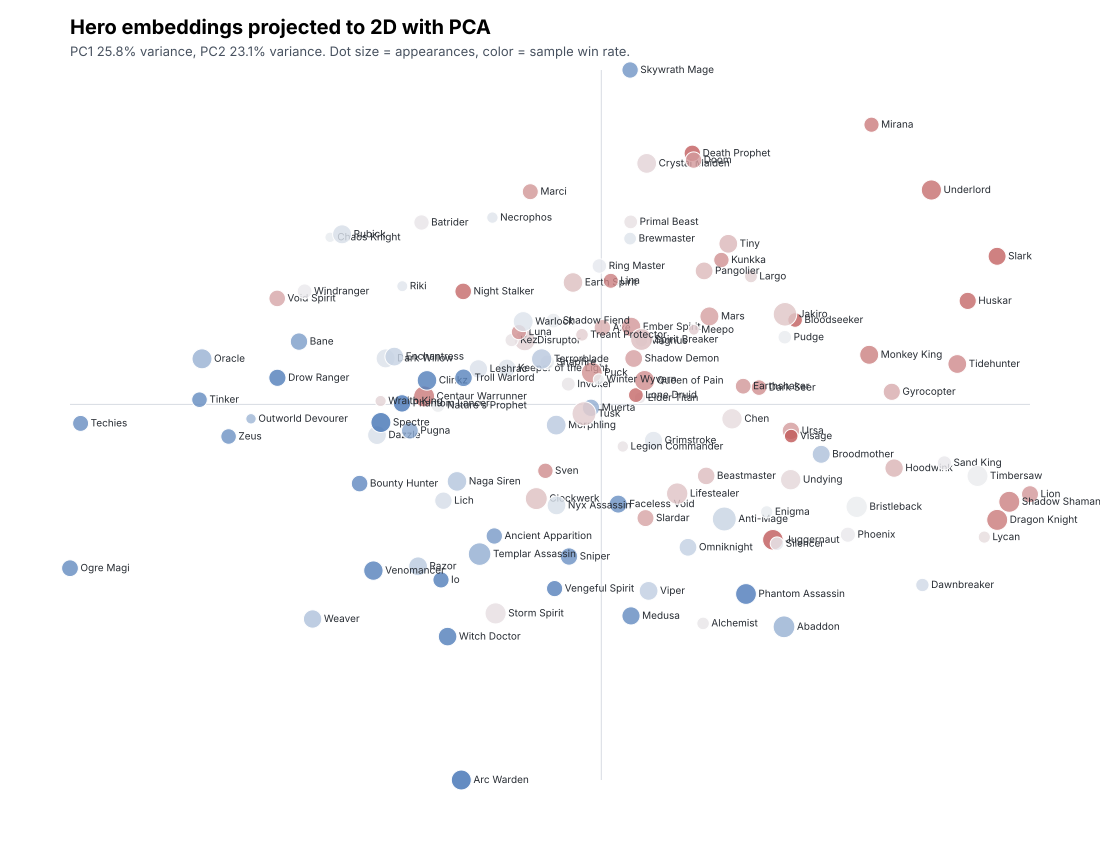

In [12]:
def pca_projection_2d(values):
    centered = values - values.mean(axis=0, keepdims=True)
    _, singular_values, components = np.linalg.svd(centered, full_matrices=False)
    coords = centered @ components[:2].T
    variance = singular_values**2
    explained = variance[:2] / variance.sum()
    return coords, explained


def color_for_win_rate(win_rate):
    if win_rate is None or np.isnan(win_rate):
        return "#8a8f98"
    t = float(np.clip(win_rate, 0.0, 1.0))
    low = np.array([61, 111, 179])
    mid = np.array([235, 237, 240])
    high = np.array([188, 73, 73])
    rgb = low + (mid - low) * (t * 2) if t < 0.5 else mid + (high - mid) * ((t - 0.5) * 2)
    return "#" + "".join(f"{int(channel):02x}" for channel in rgb)


def svg_scatter(rows, explained, *, width=1100, height=850):
    try:
        from IPython.display import SVG
    except ImportError:
        SVG = None

    margin = 70
    xs = np.array([row["x"] for row in rows])
    ys = np.array([row["y"] for row in rows])
    x_span = max(xs.max() - xs.min(), 1e-9)
    y_span = max(ys.max() - ys.min(), 1e-9)

    def sx(value):
        return margin + (value - xs.min()) / x_span * (width - 2 * margin)

    def sy(value):
        return height - margin - (value - ys.min()) / y_span * (height - 2 * margin)

    x0 = sx(0.0) if xs.min() <= 0 <= xs.max() else None
    y0 = sy(0.0) if ys.min() <= 0 <= ys.max() else None
    max_appearances = max(row["appearances"] for row in rows) or 1

    elements = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="#ffffff"/>',
        '<style>text{font-family:-apple-system,BlinkMacSystemFont,"Segoe UI",sans-serif}.label{font-size:10px;fill:#252a31}.title{font-size:20px;font-weight:650}.axis{font-size:13px;fill:#47515f}</style>',
        '<text x="70" y="34" class="title">Hero embeddings projected to 2D with PCA</text>',
        f'<text x="70" y="56" class="axis">PC1 {explained[0]:.1%} variance, PC2 {explained[1]:.1%} variance. Dot size = appearances, color = sample win rate.</text>',
    ]
    if x0 is not None:
        elements.append(f'<line x1="{x0:.1f}" y1="{margin}" x2="{x0:.1f}" y2="{height-margin}" stroke="#d7dbe2"/>')
    if y0 is not None:
        elements.append(f'<line x1="{margin}" y1="{y0:.1f}" x2="{width-margin}" y2="{y0:.1f}" stroke="#d7dbe2"/>')

    for row in rows:
        x = sx(row["x"])
        y = sy(row["y"])
        radius = 4 + 8 * np.sqrt(row["appearances"] / max_appearances)
        color = color_for_win_rate(row["win_rate"])
        label = escape(row["hero"])
        elements.append(f'<circle cx="{x:.1f}" cy="{y:.1f}" r="{radius:.1f}" fill="{color}" fill-opacity="0.82" stroke="#ffffff" stroke-width="1"/>')
        elements.append(f'<text x="{x + radius + 2:.1f}" y="{y + 3:.1f}" class="label">{label}</text>')

    elements.append("</svg>")
    svg = "".join(elements)
    return SVG(svg) if SVG else svg


coords, explained = pca_projection_2d(valid_embeddings)
hero_projection = [
    {**row, "x": float(coords[idx, 0]), "y": float(coords[idx, 1])}
    for idx, row in enumerate(hero_rows)
]

svg_scatter(hero_projection, explained)


In [13]:
embedding_norms = np.clip(np.linalg.norm(valid_embeddings, axis=1, keepdims=True), 1e-12, None)
normalized_embeddings = valid_embeddings / embedding_norms
cosine_similarity = normalized_embeddings @ normalized_embeddings.T
hero_names = [row["hero"] for row in hero_rows]


def nearest_heroes(hero_name, top_n=8):
    matches = [idx for idx, row in enumerate(hero_rows) if row["hero"].casefold() == hero_name.casefold()]
    if not matches:
        raise KeyError(f"Unknown hero name: {hero_name!r}")

    row_position = matches[0]
    order = np.argsort(-cosine_similarity[row_position])
    order = [idx for idx in order if idx != row_position][:top_n]
    return [
        {
            "hero": hero_names[idx],
            "cosine_similarity": float(cosine_similarity[row_position, idx]),
            "appearances": hero_rows[idx]["appearances"],
            "win_rate": hero_rows[idx]["win_rate"],
        }
        for idx in order
    ]


nearest_heroes("Pudge")


[{'hero': 'Huskar',
  'cosine_similarity': 0.9383969902992249,
  'appearances': 1060,
  'win_rate': 0.8962264150943396},
 {'hero': 'Earthshaker',
  'cosine_similarity': 0.8927485942840576,
  'appearances': 772,
  'win_rate': 0.7564766839378239},
 {'hero': 'Dark Seer',
  'cosine_similarity': 0.8410592675209045,
  'appearances': 733,
  'win_rate': 0.7830832196452933},
 {'hero': 'Shadow Shaman',
  'cosine_similarity': 0.7539049983024597,
  'appearances': 2127,
  'win_rate': 0.8213446168312176},
 {'hero': 'Largo',
  'cosine_similarity': 0.7530155181884766,
  'appearances': 277,
  'win_rate': 0.5848375451263538},
 {'hero': 'Lion',
  'cosine_similarity': 0.7439249157905579,
  'appearances': 994,
  'win_rate': 0.7535211267605634},
 {'hero': 'Pangolier',
  'cosine_similarity': 0.7410519123077393,
  'appearances': 1212,
  'win_rate': 0.6542904290429042},
 {'hero': 'Underlord',
  'cosine_similarity': 0.7235538363456726,
  'appearances': 1872,
  'win_rate': 0.8766025641025641}]

In [14]:
def pair_extremes(similarity, hero_names, *, top_n=20):
    upper_i, upper_j = np.triu_indices_from(similarity, k=1)
    pairs = [
        {
            "hero_a": hero_names[idx_a],
            "hero_b": hero_names[idx_b],
            "cosine_similarity": float(similarity[idx_a, idx_b]),
        }
        for idx_a, idx_b in zip(upper_i, upper_j)
    ]
    most_similar = sorted(pairs, key=lambda row: row["cosine_similarity"], reverse=True)[:top_n]
    most_different = sorted(pairs, key=lambda row: row["cosine_similarity"])[:top_n]
    return most_similar, most_different


most_similar_pairs, most_different_pairs = pair_extremes(cosine_similarity, hero_names)
most_similar_pairs


[{'hero_a': 'Naga Siren',
  'hero_b': 'Razor',
  'cosine_similarity': 0.9808745980262756},
 {'hero_a': 'Anti-Mage',
  'hero_b': 'Juggernaut',
  'cosine_similarity': 0.9808690547943115},
 {'hero_a': 'Abaddon',
  'hero_b': 'Juggernaut',
  'cosine_similarity': 0.978709876537323},
 {'hero_a': 'Abaddon',
  'hero_b': 'Anti-Mage',
  'cosine_similarity': 0.9779440760612488},
 {'hero_a': 'Dazzle',
  'hero_b': 'Techies',
  'cosine_similarity': 0.9770199060440063},
 {'hero_a': 'Disruptor',
  'hero_b': 'Treant Protector',
  'cosine_similarity': 0.968423068523407},
 {'hero_a': 'Earth Spirit',
  'hero_b': 'Luna',
  'cosine_similarity': 0.9681799411773682},
 {'hero_a': 'Drow Ranger',
  'hero_b': 'Oracle',
  'cosine_similarity': 0.9652940630912781},
 {'hero_a': 'Tinker',
  'hero_b': 'Zeus',
  'cosine_similarity': 0.9644536375999451},
 {'hero_a': 'Abaddon',
  'hero_b': 'Omniknight',
  'cosine_similarity': 0.9616586565971375},
 {'hero_a': 'Enigma',
  'hero_b': 'Silencer',
  'cosine_similarity': 0.960172

In [15]:
most_different_pairs


[{'hero_a': 'Grimstroke',
  'hero_b': 'Snapfire',
  'cosine_similarity': -0.9872123599052429},
 {'hero_a': 'Ancient Apparition',
  'hero_b': 'Kunkka',
  'cosine_similarity': -0.9835790991783142},
 {'hero_a': 'Clinkz',
  'hero_b': 'Visage',
  'cosine_similarity': -0.9830899238586426},
 {'hero_a': 'Kunkka',
  'hero_b': 'Venomancer',
  'cosine_similarity': -0.9769309759140015},
 {'hero_a': 'Doom', 'hero_b': 'Io', 'cosine_similarity': -0.975835919380188},
 {'hero_a': 'Drow Ranger',
  'hero_b': 'Lion',
  'cosine_similarity': -0.9746208786964417},
 {'hero_a': 'Bane',
  'hero_b': 'Ursa',
  'cosine_similarity': -0.9739941358566284},
 {'hero_a': 'Arc Warden',
  'hero_b': 'Skywrath Mage',
  'cosine_similarity': -0.9712104201316833},
 {'hero_a': 'Io',
  'hero_b': 'Mirana',
  'cosine_similarity': -0.9668875932693481},
 {'hero_a': 'Chaos Knight',
  'hero_b': 'Dawnbreaker',
  'cosine_similarity': -0.9641259908676147},
 {'hero_a': 'Lycan',
  'hero_b': 'Windranger',
  'cosine_similarity': -0.964090287

In [16]:
def draft_pair_counts(radiant_ids, dire_ids, num_heroes):
    ally_counts = np.zeros((num_heroes, num_heroes), dtype=int)
    enemy_counts = np.zeros((num_heroes, num_heroes), dtype=int)

    for radiant_team, dire_team in zip(radiant_ids.tolist(), dire_ids.tolist()):
        for team in (radiant_team, dire_team):
            for i, hero_a in enumerate(team):
                for hero_b in team[i + 1:]:
                    ally_counts[hero_a, hero_b] += 1
                    ally_counts[hero_b, hero_a] += 1

        for hero_a in radiant_team:
            for hero_b in dire_team:
                enemy_counts[hero_a, hero_b] += 1
                enemy_counts[hero_b, hero_a] += 1

    return ally_counts, enemy_counts


ally_counts, enemy_counts = draft_pair_counts(radiant_ids, dire_ids, num_heroes)
hero_id_to_position = {hero_id: idx for idx, hero_id in enumerate(valid_hero_ids)}

def frequent_pairs(counts, top_n=15):
    rows = []
    for hero_id_a, hero_id_b in zip(*np.triu_indices_from(counts, k=1)):
        count = counts[hero_id_a, hero_id_b]
        if count == 0 or hero_id_a not in hero_id_to_position or hero_id_b not in hero_id_to_position:
            continue
        pos_a = hero_id_to_position[hero_id_a]
        pos_b = hero_id_to_position[hero_id_b]
        rows.append({
            "hero_a": hero_names[pos_a],
            "hero_b": hero_names[pos_b],
            "draft_count": int(count),
            "embedding_cosine": float(cosine_similarity[pos_a, pos_b]),
        })
    return sorted(rows, key=lambda row: (row["draft_count"], row["embedding_cosine"]), reverse=True)[:top_n]


frequent_ally_pairs = frequent_pairs(ally_counts)
frequent_enemy_pairs = frequent_pairs(enemy_counts)
frequent_ally_pairs


[{'hero_a': 'Anti-Mage',
  'hero_b': 'Templar Assassin',
  'draft_count': 715,
  'embedding_cosine': 0.36529260873794556},
 {'hero_a': 'Anti-Mage',
  'hero_b': 'Spectre',
  'draft_count': 568,
  'embedding_cosine': -0.30693507194519043},
 {'hero_a': 'Anti-Mage',
  'hero_b': 'Phantom Assassin',
  'draft_count': 562,
  'embedding_cosine': 0.5794076919555664},
 {'hero_a': 'Phantom Assassin',
  'hero_b': 'Templar Assassin',
  'draft_count': 553,
  'embedding_cosine': 0.32162582874298096},
 {'hero_a': 'Phantom Assassin',
  'hero_b': 'Arc Warden',
  'draft_count': 552,
  'embedding_cosine': 0.4666222035884857},
 {'hero_a': 'Templar Assassin',
  'hero_b': 'Arc Warden',
  'draft_count': 546,
  'embedding_cosine': 0.9333662390708923},
 {'hero_a': 'Spectre',
  'hero_b': 'Arc Warden',
  'draft_count': 543,
  'embedding_cosine': 0.020428847521543503},
 {'hero_a': 'Phantom Assassin',
  'hero_b': 'Spectre',
  'draft_count': 534,
  'embedding_cosine': -0.25127553939819336},
 {'hero_a': 'Anti-Mage',
 

In [17]:
frequent_enemy_pairs


[{'hero_a': 'Anti-Mage',
  'hero_b': 'Earth Spirit',
  'draft_count': 570,
  'embedding_cosine': -0.3779903054237366},
 {'hero_a': 'Anti-Mage',
  'hero_b': 'Jakiro',
  'draft_count': 531,
  'embedding_cosine': 0.05024702474474907},
 {'hero_a': 'Anti-Mage',
  'hero_b': 'Storm Spirit',
  'draft_count': 504,
  'embedding_cosine': 0.28106772899627686},
 {'hero_a': 'Templar Assassin',
  'hero_b': 'Jakiro',
  'draft_count': 455,
  'embedding_cosine': -0.1360916942358017},
 {'hero_a': 'Templar Assassin',
  'hero_b': 'Earth Spirit',
  'draft_count': 446,
  'embedding_cosine': -0.7390255331993103},
 {'hero_a': 'Anti-Mage',
  'hero_b': 'Disruptor',
  'draft_count': 423,
  'embedding_cosine': -0.35078272223472595},
 {'hero_a': 'Anti-Mage',
  'hero_b': 'Grimstroke',
  'draft_count': 418,
  'embedding_cosine': 0.2124302089214325},
 {'hero_a': 'Templar Assassin',
  'hero_b': 'Tusk',
  'draft_count': 416,
  'embedding_cosine': -0.047694966197013855},
 {'hero_a': 'Jakiro',
  'hero_b': 'Abaddon',
  'dr

## Manual draft prediction

In [18]:
def predict_manual_draft(model, radiant_heroes, dire_heroes, *, env_file=str(PROJECT_ROOT / ".env")):
    if len(radiant_heroes) != 5:
        raise ValueError(f"radiant_heroes must contain 5 heroes, got {len(radiant_heroes)}")
    if len(dire_heroes) != 5:
        raise ValueError(f"dire_heroes must contain 5 heroes, got {len(dire_heroes)}")

    with DatasetMaker(env_file=env_file) as dataset:
        radiant_ids = [dataset.hero_name_to_id(hero) for hero in radiant_heroes]
        dire_ids = [dataset.hero_name_to_id(hero) for hero in dire_heroes]

    radiant_tensor = torch.tensor([radiant_ids], dtype=torch.long, device=device)
    dire_tensor = torch.tensor([dire_ids], dtype=torch.long, device=device)

    model.eval()
    with torch.no_grad():
        logit = model(radiant_tensor, dire_tensor).item()
        p_dire = torch.sigmoid(torch.tensor(logit)).item()

    return {
        "radiant_ids": radiant_ids,
        "dire_ids": dire_ids,
        "logit": logit,
        "p_radiant": 1.0 - p_dire,
        "p_dire": p_dire,
        "predicted_winner": "dire" if p_dire >= 0.5 else "radiant",
    }

In [19]:
radiant_heroes = [
    "keeper of the light",
    "axe",
    "phantom assassin",
    "ogre magi",
    "lion",
]

dire_heroes = [
    "bristleback",
    "huskar",
    "phoenix",
    "ember spirit",
    "juggernaut",
]

predict_manual_draft(model, radiant_heroes, dire_heroes)

{'radiant_ids': [90, 2, 44, 84, 26],
 'dire_ids': [99, 59, 110, 106, 8],
 'logit': 0.44666603207588196,
 'p_radiant': 0.390153706073761,
 'p_dire': 0.609846293926239,
 'predicted_winner': 'dire'}